In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
mail_dataset=pd.read_csv("Mall_Customers.csv")
mail_dataset

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
mail_dataset.shape

(200, 5)

In [5]:
mail_dataset.describe

<bound method NDFrame.describe of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

In [6]:
mail_dataset.info

<bound method DataFrame.info of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

In [7]:
mail_dataset.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [19]:
from sklearn.preprocessing import LabelEncoder  
le= LabelEncoder()
for col in mail_dataset.columns:
    if mail_dataset[col].dtype == 'object':
        mail_dataset[col] = le.fit_transform(mail_dataset[col])

In [20]:
mail_dataset.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

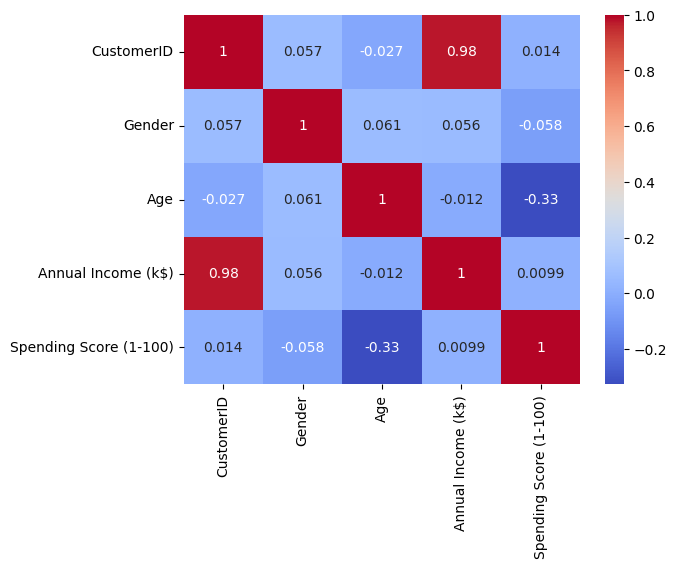

<Figure size 1200x1600 with 0 Axes>

In [22]:
corr=mail_dataset.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.figure(figsize=(12,16))
plt.show()

In [23]:
SpendingScore=mail_dataset['Annual Income (k$)'].values
Segmentation=mail_dataset['Spending Score (1-100)'].values 
age=mail_dataset['Age'].values

X=np.array(list(zip(SpendingScore,Segmentation,age)))
print(X)

[[ 15  39  19]
 [ 15  81  21]
 [ 16   6  20]
 [ 16  77  23]
 [ 17  40  31]
 [ 17  76  22]
 [ 18   6  35]
 [ 18  94  23]
 [ 19   3  64]
 [ 19  72  30]
 [ 19  14  67]
 [ 19  99  35]
 [ 20  15  58]
 [ 20  77  24]
 [ 20  13  37]
 [ 20  79  22]
 [ 21  35  35]
 [ 21  66  20]
 [ 23  29  52]
 [ 23  98  35]
 [ 24  35  35]
 [ 24  73  25]
 [ 25   5  46]
 [ 25  73  31]
 [ 28  14  54]
 [ 28  82  29]
 [ 28  32  45]
 [ 28  61  35]
 [ 29  31  40]
 [ 29  87  23]
 [ 30   4  60]
 [ 30  73  21]
 [ 33   4  53]
 [ 33  92  18]
 [ 33  14  49]
 [ 33  81  21]
 [ 34  17  42]
 [ 34  73  30]
 [ 37  26  36]
 [ 37  75  20]
 [ 38  35  65]
 [ 38  92  24]
 [ 39  36  48]
 [ 39  61  31]
 [ 39  28  49]
 [ 39  65  24]
 [ 40  55  50]
 [ 40  47  27]
 [ 40  42  29]
 [ 40  42  31]
 [ 42  52  49]
 [ 42  60  33]
 [ 43  54  31]
 [ 43  60  59]
 [ 43  45  50]
 [ 43  41  47]
 [ 44  50  51]
 [ 44  46  69]
 [ 46  51  27]
 [ 46  46  53]
 [ 46  56  70]
 [ 46  55  19]
 [ 47  52  67]
 [ 47  59  54]
 [ 48  51  63]
 [ 48  59  18]
 [ 48  50 

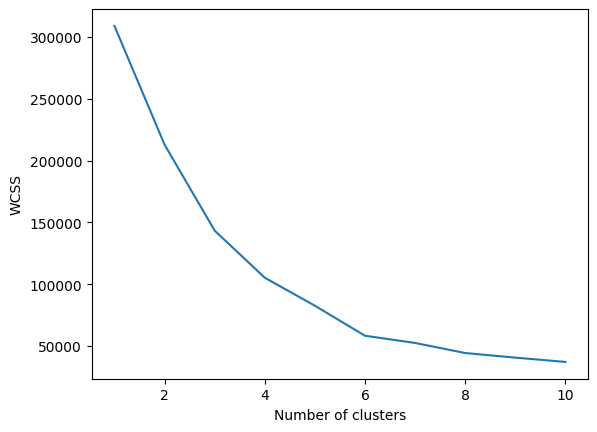

In [11]:
wcss=[]

for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=0)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
print(list(wcss))

[308812.77999999997, 212840.16982097187, 143342.751571706, 105251.108132205, 82608.63809385583, 58338.70237980936, 52496.58948832717, 44342.3173934174, 40623.36547212477, 37153.67212762972]


In [13]:
#k=4
model=KMeans(n_clusters=4,random_state=42)
y_means=model.fit_predict(X)
y_means

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

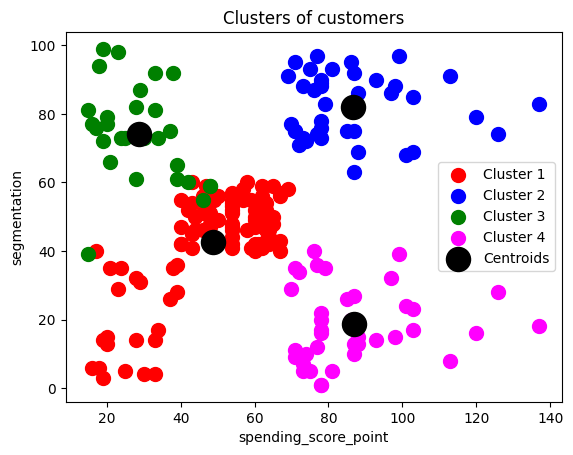

In [16]:
plt.scatter(X[y_means==0, 0], X[y_means==0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_means==1, 0], X[y_means==1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_means==2, 0], X[y_means==2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_means==3, 0], X[y_means==3, 1], s=100, c='magenta', label='Cluster 4')

plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=300, c='black', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('spending_score_point')
plt.ylabel('segmentation')
plt.legend()
plt.show()
